##  Loading ECG Dataset

In [329]:
from scipy.signal import butter,filtfilt

In [330]:
import scipy.io

In [331]:
!pip install wfdb
import wfdb
# to load and read out signal

In [332]:
import matplotlib.pyplot as plt
import numpy as np
import scipy

In [333]:
record_name = '00001_hr'
pn_dir = 'ptb-xl/1.0.3/records500/00000/'

In [334]:
record = wfdb.rdrecord(record_name, pn_dir=pn_dir)

In [335]:
signal = record.p_signal
fs = record.fs
print("Sampling Rate:",fs)
print("Signal Shape:",signal.shape)


Sampling Rate: 500
Signal Shape: (5000, 12)


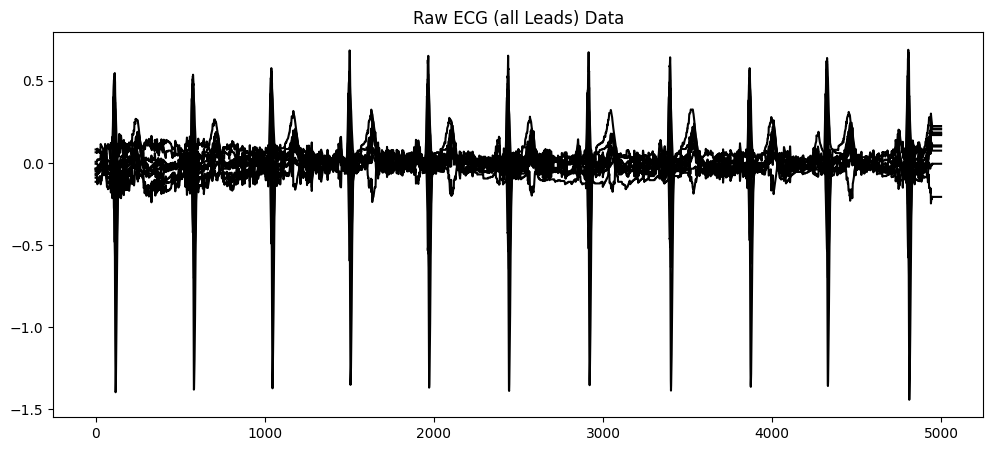

In [336]:
plt.figure(figsize = (12,5))
plt.plot(signal, color = "black")
plt.title("Raw ECG (all Leads) Data")
plt.show()

In [337]:
print(signal.shape)

(5000, 12)


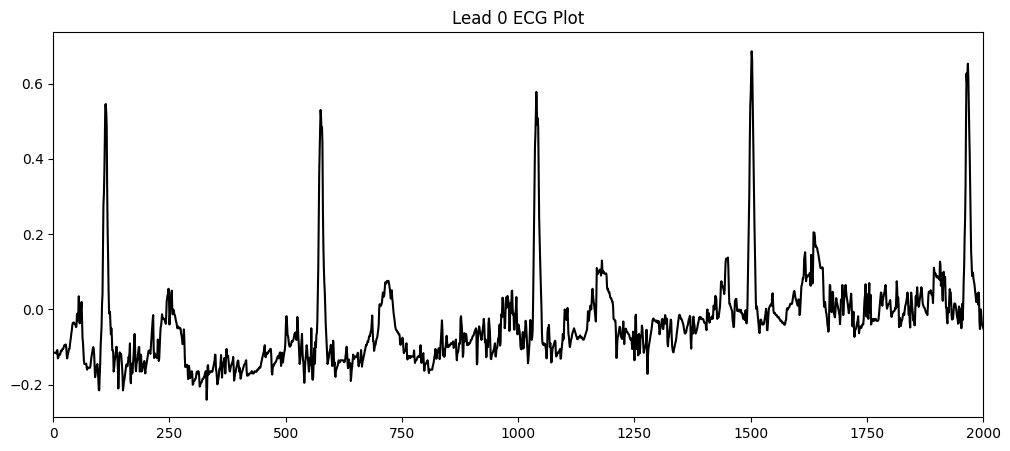

In [338]:
plt.figure(figsize = (12,5))
plt.plot(signal[:,0], color = "black") # 0th Lead Plot
plt.title("Lead 0 ECG Plot")
plt.xlim(0,2000)
plt.show()

##Define BandPass Filter

In [339]:
def bandpass_filter(signal, lowcut, highcut,
                    fs, order=2):
  nyquist = 0.5*fs  #nyquist rate,
#twice the frequency of signal to avoid distortion
#once we try to obtain signal back from sampled version
  low = lowcut/nyquist
# lowcut & highcut are frequency boundaries
  high = highcut/nyquist
# Coefficients
  b, a = butter(order,[low,high], btype = "band") #bandpass
#filter function
  y = filtfilt(b, a, signal, axis=0)
  return y
#Sample value
lowcut = 0.5
highcut = 15.0

## Bandpass Filtering (0.5–15 Hz)


In [340]:
filter_signal = bandpass_filter(signal, lowcut, highcut, fs)

In [341]:
ecg = filter_signal[:1000,0]

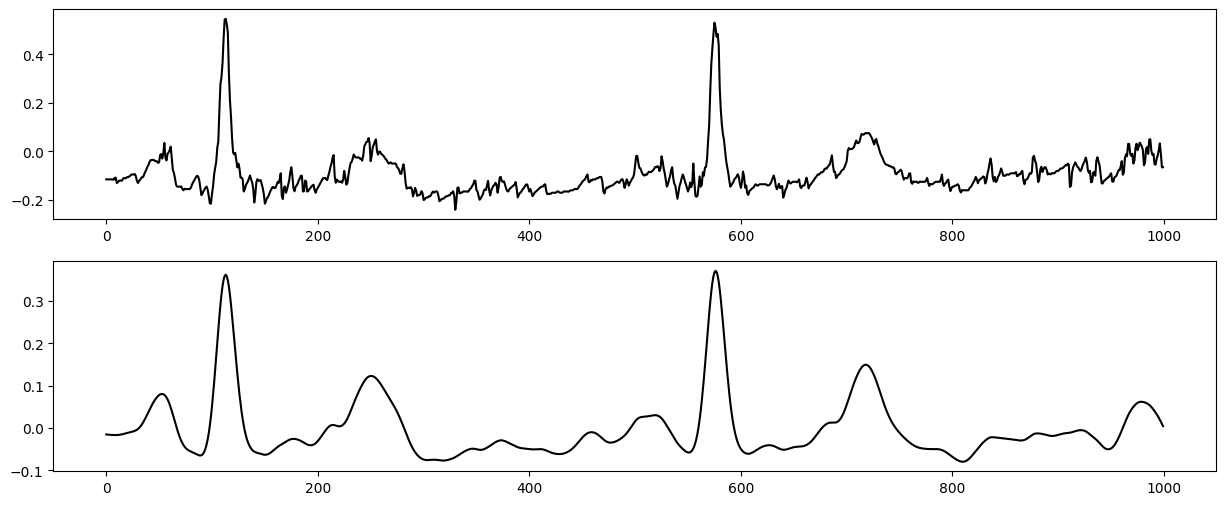

In [342]:
plt.figure(figsize = (15,6))

plt.subplot(2,1,1)
plt.plot(signal[:1000,0], color = "black", label="Actual Signal")

plt.subplot(2,1,2)
plt.plot(ecg, color = "black", label="Filtered Signal")

plt.show()


### We have filtered, now we must reobtain our original signal for further processing

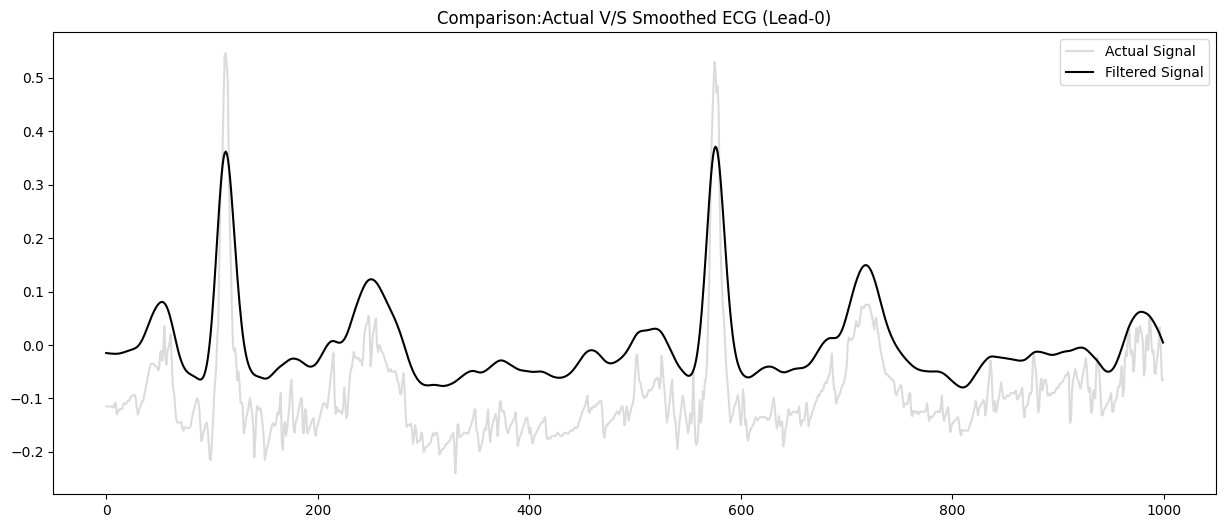

In [343]:
plt.figure(figsize=(15,6))
plt.plot(signal[:1000,0], color='lightgray', label='Actual Signal', alpha=0.8)
plt.plot(ecg, color='black', label='Filtered Signal')

plt.title("Comparison:Actual V/S Smoothed ECG (Lead-0)")
plt.legend()
plt.show()

#Pan tompkins Algorithm

### 1. Find derivate of signal data points
### 2. square the signal
### 3. Implement the moving window

## -> Derivative Stage


In [344]:
def derivative_filter(ecg_signal, fs = record.fs):
  kernel = np.array([-1,-2,0,1,2])/8
  derivative = np.convolve(ecg_signal,kernel,mode="same")
  # the mode thing is for maintaining the size of
  # output array same as input
  return derivative


In [345]:
der = derivative_filter(filter_signal[:,0])

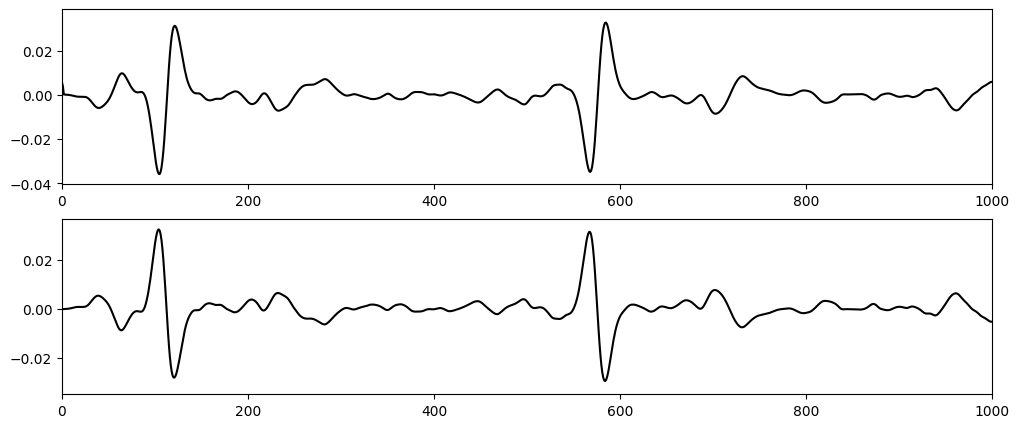

In [346]:
plt.figure(figsize = (12,5))
plt.subplot(2,1,1)
plt.plot(der, color = "black")
plt.xlim(0,1000)

plt.subplot(2,1,2)
plt.plot(np.diff(filter_signal[:,0]), color = "black")
plt.xlim(0,1000)
plt.show()


## -> Squaring Function

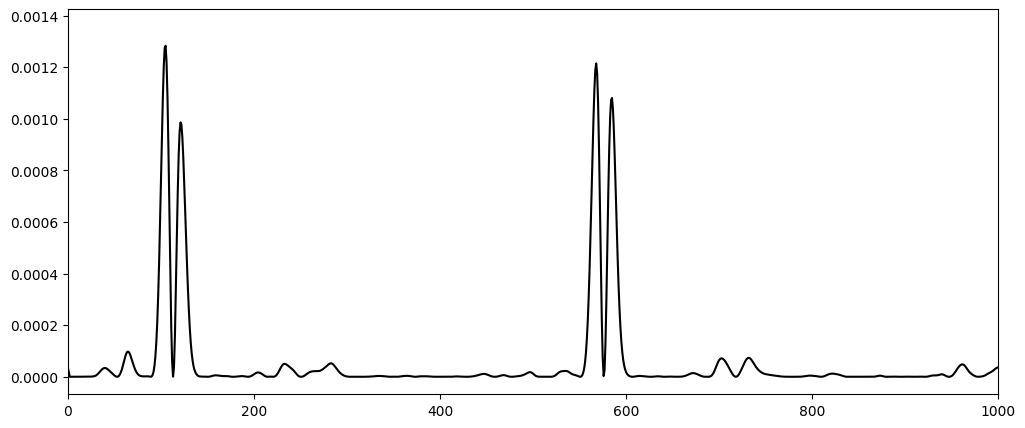

In [347]:
squared_signal = der**2
plt.figure(figsize = (12,5))
plt.plot(squared_signal, color = "black")
plt.xlim(0,1000)
plt.show()

## -> Moving Window Integration

In [348]:
def moving_window(signal, fs = record.fs, window_ms = 150):
  window_size = int((window_ms/1000)*fs)
  window = np.ones(window_size)/window_size
  integrated = np.convolve(signal, window, mode="same")
  return integrated

In [349]:
window_signal = moving_window(squared_signal,fs)

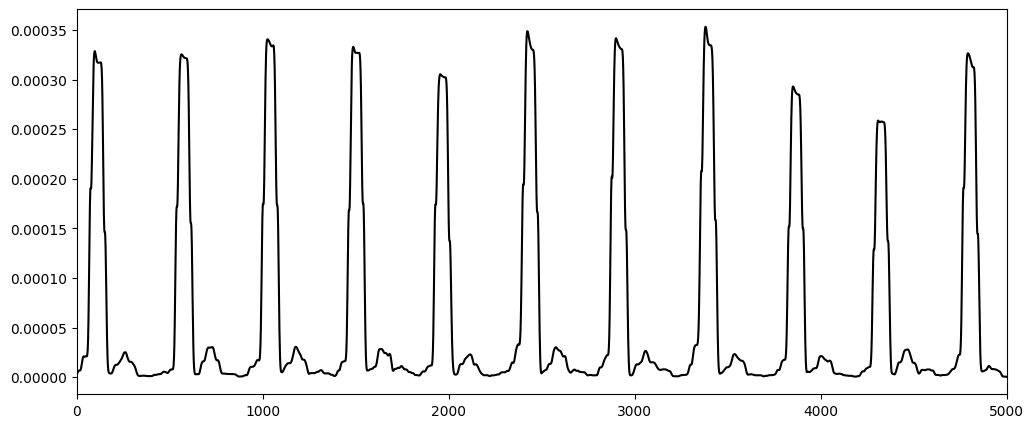

In [350]:
plt.figure(figsize = (12,5))
plt.plot(window_signal, color = "black")
plt.xlim(0,5000)
plt.show()

## R Peak Detection

In [351]:
def Rpeaks_detection(signal, fs = record.fs):

  threshold = np.mean(signal) + 0.4*(np.max(signal)-np.mean(signal))
  min_distance = int(0.3 * fs)

  peaks = []
  length = len(signal)

  for i in range(1, length-1):
    if signal[i] > signal[i-1] and signal[i] > signal[i+1] and signal[i] > threshold:

      if not peaks or (i-peaks[-1]>=min_distance):
        peaks.append(i)
      else:
        if signal[i] > signal[peaks[-1]]:
          peaks[-1] = i

  return np.array(peaks)


In [352]:
r_peaks = Rpeaks_detection(filter_signal[:,0],fs)

In [353]:
print(r_peaks)

[ 113  576 1040 1502 1967 2439 2915 3396 3867 4324 4806]


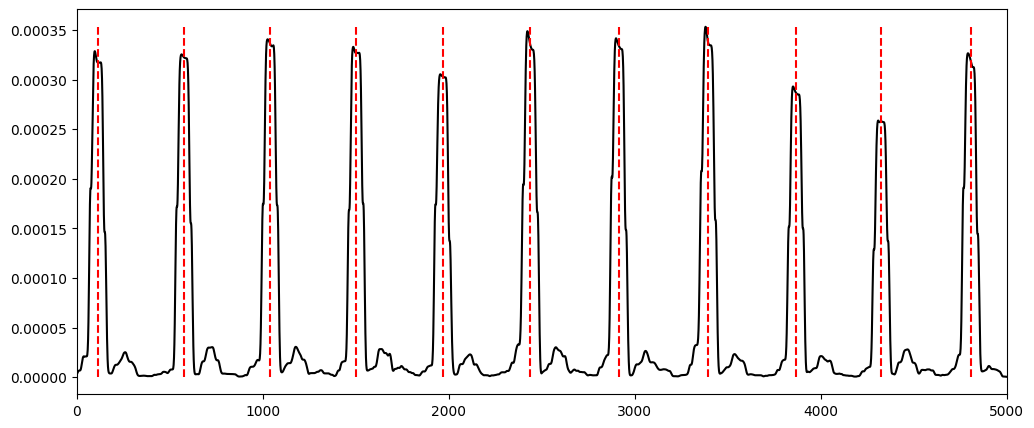

In [354]:
plt.figure(figsize = (12,5))
plt.plot(window_signal, color = "black")
plt.vlines(r_peaks, ymin=min(window_signal), ymax=max(window_signal), color = "red", linestyle = '--')
plt.xlim(0,5000)
plt.show()

## Q & S Subpeak Detection

In [355]:
def detect_q_s(filter_signal, r_peaks, fs):

    q_peaks = []
    s_peaks = []

    search_window = int(0.08 * fs)

    for r in r_peaks:

        left = max(0, r-search_window)
        right = min(len(filter_signal), r+search_window)

        # q point = minimum before r_peak
        q_region = filter_signal[left:r]
        if len(q_region) > 0:
            q = left+np.argmin(q_region)
            q_peaks.append(q)

        # s point = minimum after r_peak
        s_region = filter_signal[r:right]
        if len(s_region) > 0:
            s = r+np.argmin(s_region)
            s_peaks.append(s)

    return np.array(q_peaks), np.array(s_peaks)

In [356]:
q_peaks, s_peaks = detect_q_s(filter_signal[:,0], r_peaks, fs)

In [357]:
start_sec = 0
end_sec = 10
start_idx = int(start_sec* fs)
end_idx = int(end_sec* fs)

r_peaks = Rpeaks_detection(filter_signal[:,0],fs)
q_peaks, s_peaks = detect_q_s(filter_signal[:,0], r_peaks, fs)

# slice the signal and create time axis
signal_slice = filter_signal[start_idx:end_idx,0]

time_slice = np.arange(start_idx,end_idx)/fs

r_plot = r_peaks[(r_peaks >= start_idx) & (r_peaks < end_idx)]
q_plot = q_peaks[(q_peaks >= start_idx) & (q_peaks < end_idx)]
s_plot = s_peaks[(s_peaks >= start_idx) & (s_peaks < end_idx)]

In [358]:
print(r_plot)
print(q_plot)
print(s_plot)

[ 113  576 1040 1502 1967 2439 2915 3396 3867 4324 4806]
[  89  551 1015 1478 1943 2414 2891 3369 3843 4299 4783]
[ 150  607 1071 1526 1999 2463 2941 3423 3891 4349 4843]


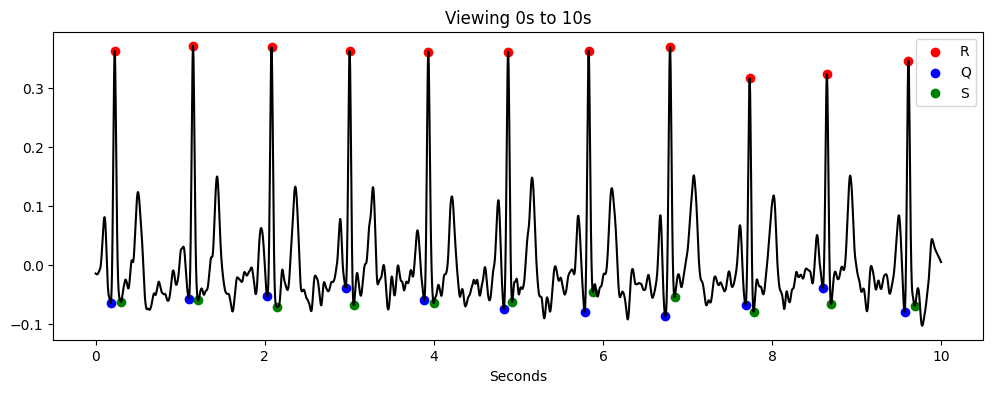

In [359]:
plt.figure(figsize=(12, 4))
plt.plot(time_slice, signal_slice, color='black')

plt.scatter(r_plot / fs, filter_signal[r_plot, 0], color='red', label='R')
plt.scatter(q_plot / fs, filter_signal[q_plot, 0], color='blue', label='Q')
plt.scatter(s_plot / fs, filter_signal[s_plot, 0], color='green', label='S')

plt.legend()
plt.xlabel("Seconds")
plt.title(f"Viewing {start_sec}s to {end_sec}s")
plt.show()

 ## Heart Rate Calculation

In [360]:
rr_intervals_samples = np.diff(r_peaks)
rr_intervals_sec = rr_intervals_samples / fs
instantaneous_bpm = 60 / rr_intervals_sec

average_bpm = np.mean(instantaneous_bpm)
standard_bpm = np.std(instantaneous_bpm) # Heart Rate Variability(HRV)

print(f"Average Heart Rate: {average_bpm:.2f} BPM")
print(f"BPM Range: {np.min(instantaneous_bpm):.1f} - {np.max(instantaneous_bpm):.1f}")

Average Heart Rate: 63.94 BPM
BPM Range: 62.2 - 65.6
